In [3]:
import networkx as nx
import pandas as pd

G = nx.read_graphml("data/processed/broadway_network_clean.graphml")

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", nx.density(G))
print("Connected components:", nx.number_connected_components(G))

Nodes: 55261
Edges: 1565292
Density: 0.001025169651446366
Connected components: 285


In [4]:
largest_component = max(nx.connected_components(G), key=len)

print("Largest component size:", len(largest_component))
print("Largest component share:", f"{len(largest_component)/G.number_of_nodes():.2%}")

Largest component size: 52874
Largest component share: 95.68%


In [5]:
degree_df = pd.DataFrame(
    G.degree(),
    columns=["performer_id", "degree"]
)

degree_df.head()

,performer_id,degree
0,A_473388,26
1,A_34408,26
2,A_473389,113
3,A_35813,26
4,A_438924,26


In [6]:
strength_df = pd.DataFrame(
    G.degree(weight="weight"),
    columns=["performer_id", "weighted_degree"]
)

strength_df.head()

,performer_id,weighted_degree
0,A_473388,26
1,A_34408,26
2,A_473389,114
3,A_35813,26
4,A_438924,26


In [17]:
# Extract performer names from graph attributes
name_df = pd.DataFrame(
    [
        (node, data.get("performer_name"))
        for node, data in G.nodes(data=True)
    ],
    columns=["performer_id", "performer_name"]
)

name_df.head()

,performer_id,performer_name
0,A_473388,Dot Campbell
1,A_34408,Raymond Campbell
2,A_473389,Alice Carter
3,A_35813,Louis Cole
4,A_438924,Craddock and Shadney


,performer_id,degree,weighted_degree,performer_name
0,A_473388,26,26,Dot Campbell
1,A_34408,26,26,Raymond Campbell
2,A_473389,113,114,Alice Carter
3,A_35813,26,26,Louis Cole
4,A_438924,26,26,Craddock and Shadney


In [23]:
performer_metrics = degree_df.merge(
    strength_df,
    on="performer_id"
)

performer_metrics.head()

,performer_id,degree,weighted_degree
0,A_473388,26,26
1,A_34408,26,26
2,A_473389,113,114
3,A_35813,26,26
4,A_438924,26,26


In [24]:
performer_metrics = performer_metrics.merge(
    name_df,
    on="performer_id",
    how="left"
)

performer_metrics.head()

,performer_id,degree,weighted_degree,performer_name
0,A_473388,26,26,Dot Campbell
1,A_34408,26,26,Raymond Campbell
2,A_473389,113,114,Alice Carter
3,A_35813,26,26,Louis Cole
4,A_438924,26,26,Craddock and Shadney


In [25]:
performer_metrics.sort_values(
    "degree",
    ascending=False
).head(20)

,performer_id,degree,weighted_degree,performer_name
198,A_53589,720,817,Victor Moore
401,A_68475,700,797,Le Roi Operti
3932,A_21639,698,711,Dennis King
8265,A_35584,692,797,Dudley Clements
21693,A_21617,675,749,David Wayne
4393,A_52148,652,669,Charles McClelland
2525,A_67079,649,688,Robert Chisholm
11659,A_39487,642,697,Maurice Ellis
36366,A_66920,640,928,Philip Bosco
2028,A_14598,634,663,Clarence Derwent


In [26]:
performer_metrics.sort_values(
    "weighted_degree",
    ascending=False
).head(20)

,performer_id,degree,weighted_degree,performer_name
8963,A_31313,432,1202,Frances Baviello
7335,A_67230,292,938,William Danforth
36366,A_66920,640,928,Philip Bosco
3835,A_31445,593,898,Walter Beck
9332,A_67205,424,844,Roy Cropper
198,A_53589,720,817,Victor Moore
768,A_63759,317,811,Gertrude Waldon
8265,A_35584,692,797,Dudley Clements
401,A_68475,700,797,Le Roi Operti
7118,A_29794,512,788,Florenz Ames


In [28]:
performer_metrics["collaboration_intensity"] = (
    performer_metrics["weighted_degree"] /
    performer_metrics["degree"]
)

performer_metrics.sort_values(
    "collaboration_intensity",
    ascending=False
).head(20)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity
14974,A_68277,19,195,F.J. McCormick,10.263158
14972,A_67345,19,181,Michael J. Dolan,9.526316
14968,A_67028,19,174,P.J. Carolan,9.157895
14969,A_36573,19,165,May Craig,8.684211
14971,A_67308,27,189,Maureen Delany,7.000000
33064,A_116861,25,174,A. Mendez,6.960000
33065,A_116858,25,174,Emilio Menendez,6.960000
33066,A_116866,25,174,Antonio Mora,6.960000
33067,A_116862,25,174,Pilar Olivar,6.960000
33059,A_40385,25,174,Francisca Ferrandiz,6.960000


In [29]:
high_degree_intensity = performer_metrics[
    performer_metrics["degree"] >= 100
].sort_values(
    "collaboration_intensity",
    ascending=False
)

high_degree_intensity.head(20)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity
12857,A_15732,190,733,Frank Moulan,3.857895
23794,A_103548,101,340,Catherine Judah,3.366337
12853,A_79471,105,347,Patricia Clark,3.304762
7335,A_67230,292,938,William Danforth,3.212329
12858,A_54613,101,318,Felix Noonan,3.148515
12861,A_59348,189,593,Olga Schumacher,3.137566
12981,A_383656,104,322,Isabel Norwood,3.096154
13471,A_63807,133,409,Margaret Walker,3.075188
12985,A_64076,103,315,Allan Ware,3.058252
17177,A_67666,191,582,Martyn Green,3.047120


In [30]:
performer_metrics[
    performer_metrics["degree"] >= 300
].sort_values(
    "collaboration_intensity",
    ascending=False
).head(20)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity
8963,A_31313,432,1202,Frances Baviello,2.782407
768,A_63759,317,811,Gertrude Waldon,2.558360
9332,A_67205,424,844,Roy Cropper,1.990566
1667,A_5481,333,623,Eva Le Gallienne,1.870871
38409,A_57935,328,574,Robert Phalen,1.750000
1344,A_116140,316,535,George Koenig,1.693038
38413,A_16305,309,492,Robert Symonds,1.592233
9587,A_68761,305,485,Art Smith,1.590164
27067,A_84427,347,551,Ray Fry,1.587896
7118,A_29794,512,788,Florenz Ames,1.539062


In [31]:
performer_metrics["repeat_collaboration_surplus"] = (
    performer_metrics["weighted_degree"] -
    performer_metrics["degree"]
)

performer_metrics["repeat_collaboration_ratio"] = (
    performer_metrics["repeat_collaboration_surplus"] /
    performer_metrics["degree"]
)

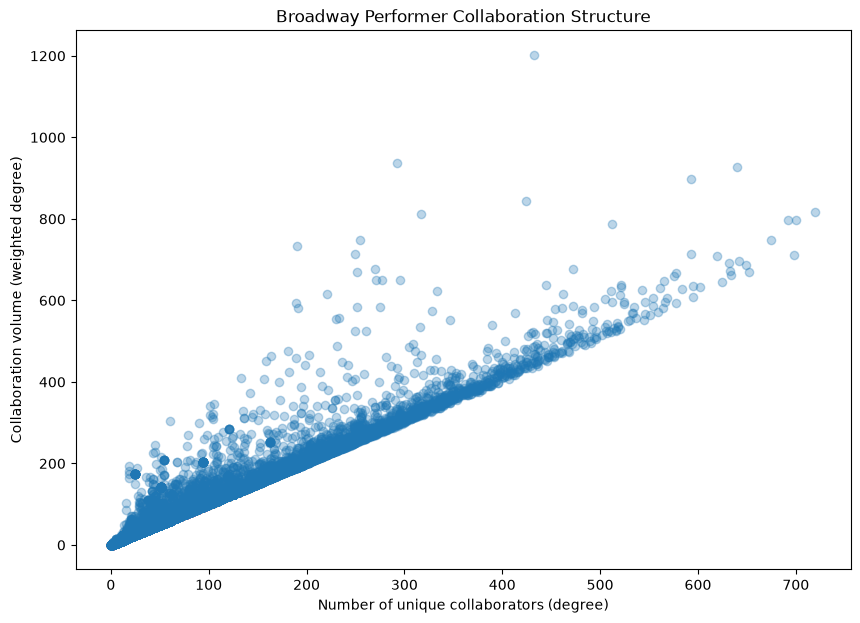

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

plt.scatter(
    performer_metrics["degree"],
    performer_metrics["weighted_degree"],
    alpha=0.3
)

plt.xlabel("Number of unique collaborators (degree)")
plt.ylabel("Collaboration volume (weighted degree)")
plt.title("Broadway Performer Collaboration Structure")

plt.show()

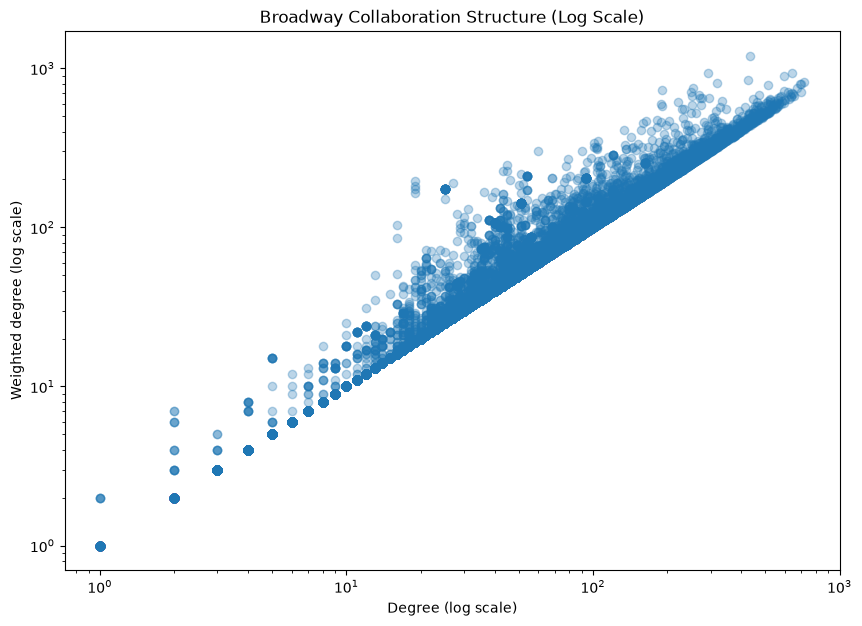

In [33]:
plt.figure(figsize=(10, 7))

plt.scatter(
    performer_metrics["degree"],
    performer_metrics["weighted_degree"],
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree (log scale)")
plt.ylabel("Weighted degree (log scale)")
plt.title("Broadway Collaboration Structure (Log Scale)")

plt.show()

In [35]:
performer_metrics["weighted_degree_residual"] = (
    performer_metrics["weighted_degree"] /
    performer_metrics["degree"]
)

performer_metrics[
    performer_metrics["degree"] >= 100
].sort_values(
    "weighted_degree_residual",
    ascending=False
).head(20)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity,repeat_collaboration_surplus,repeat_collaboration_ratio,weighted_degree_residual
12857,A_15732,190,733,Frank Moulan,3.857895,543,2.857895,3.857895
23794,A_103548,101,340,Catherine Judah,3.366337,239,2.366337,3.366337
12853,A_79471,105,347,Patricia Clark,3.304762,242,2.304762,3.304762
7335,A_67230,292,938,William Danforth,3.212329,646,2.212329,3.212329
12858,A_54613,101,318,Felix Noonan,3.148515,217,2.148515,3.148515
12861,A_59348,189,593,Olga Schumacher,3.137566,404,2.137566,3.137566
12981,A_383656,104,322,Isabel Norwood,3.096154,218,2.096154,3.096154
13471,A_63807,133,409,Margaret Walker,3.075188,276,2.075188,3.075188
12985,A_64076,103,315,Allan Ware,3.058252,212,2.058252,3.058252
17177,A_67666,191,582,Martyn Green,3.047120,391,2.047120,3.047120


In [37]:
pagerank = nx.pagerank(G)

pagerank_df = pd.DataFrame(
    pagerank.items(),
    columns=["performer_id", "pagerank"]
)

performer_metrics = performer_metrics.merge(
    pagerank_df,
    on="performer_id"
)

performer_metrics.sort_values(
    "pagerank",
    ascending=False
).head(20)

KeyError: 'pagerank'

In [39]:
performer_metrics = performer_metrics.drop(
    columns=["pagerank_x"]
)

performer_metrics = performer_metrics.rename(
    columns={"pagerank_y": "pagerank"}
)

In [40]:
performer_metrics.sort_values(
    "pagerank",
    ascending=False
).head(20)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity,repeat_collaboration_surplus,repeat_collaboration_ratio,weighted_degree_residual,pagerank
36366,A_66920,640,928,Philip Bosco,1.450000,288,0.450000,1.450000,0.000285
30862,A_67892,595,609,George S. Irving,1.023529,14,0.023529,1.023529,0.000179
33873,A_57887,554,586,Chita Rivera,1.057762,32,0.057762,1.057762,0.000178
3932,A_21639,698,711,Dennis King,1.018625,13,0.018625,1.018625,0.000176
41474,A_50271,452,546,Patti LuPone,1.207965,94,0.207965,1.207965,0.000173
17768,A_66926,565,648,Philip Bourneuf,1.146903,83,0.146903,1.146903,0.000169
2028,A_14598,634,663,Clarence Derwent,1.045741,29,0.045741,1.045741,0.000169
4093,A_67134,568,605,Francis Compton,1.065141,37,0.065141,1.065141,0.000168
401,A_68475,700,797,Le Roi Operti,1.138571,97,0.138571,1.138571,0.000164
2278,A_67027,472,676,Morris Carnovsky,1.432203,204,0.432203,1.432203,0.000163


In [41]:
metrics = performer_metrics[
    [
        "degree",
        "weighted_degree",
        "pagerank",
        "collaboration_intensity",
        "repeat_collaboration_ratio"
    ]
]

metrics.corr().round(3)

,degree,weighted_degree,pagerank,collaboration_intensity,repeat_collaboration_ratio
degree,1.000,0.976,0.870,0.051,0.051
weighted_degree,0.976,1.000,0.877,0.197,0.197
pagerank,0.870,0.877,1.000,0.130,0.130
collaboration_intensity,0.051,0.197,0.130,1.000,1.000
repeat_collaboration_ratio,0.051,0.197,0.130,1.000,1.000


In [44]:
top_degree = set(
    performer_metrics.nlargest(20, "degree")["performer_name"]
)

top_pagerank = set(
    performer_metrics.nlargest(20, "pagerank")["performer_name"]
)

print(len(top_degree & top_pagerank))

print("Only in degree:", sorted(top_degree - top_pagerank))
print("Only in PageRank:", sorted(top_pagerank - top_degree))

9
Only in degree: ['Charles McClelland', 'Dudley Clements', 'Ethel Merman', 'Harry Bellaver', 'Maurice Ellis', 'Robert Chisholm', 'Victor Moore', 'Virginia Allen', 'Ward Tallman', 'William Gaxton', 'Wilma Roeloff']
Only in PageRank: ['Audra McDonald', 'Chita Rivera', 'Francis Compton', 'Frederic Tozere', 'Helen Hayes', 'José Ferrer', 'Morris Carnovsky', 'Patti LuPone', 'Philip Bourneuf', 'Sam Levene', 'Tom Aldredge']


In [45]:
pagerank_weighted = nx.pagerank(G, weight="weight")

In [46]:
GC = G.subgraph(max(nx.connected_components(G), key=len)).copy()

nx.average_clustering(GC)
nx.degree_assortativity_coefficient(GC)

0.16139438236719508

In [48]:
weighted_pr_df = pd.DataFrame(
    pagerank_weighted.items(),
    columns=["performer_id", "pagerank_weighted"]
)

performer_metrics = performer_metrics.merge(
    weighted_pr_df,
    on="performer_id",
    how="left"
)

In [49]:
performer_metrics.sort_values(
    "pagerank_weighted",
    ascending=False
).head(20)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity,repeat_collaboration_surplus,repeat_collaboration_ratio,weighted_degree_residual,pagerank,pagerank_weighted
36366,A_66920,640,928,Philip Bosco,1.450000,288,0.450000,1.450000,0.000285,0.000285
30862,A_67892,595,609,George S. Irving,1.023529,14,0.023529,1.023529,0.000179,0.000179
33873,A_57887,554,586,Chita Rivera,1.057762,32,0.057762,1.057762,0.000178,0.000178
3932,A_21639,698,711,Dennis King,1.018625,13,0.018625,1.018625,0.000176,0.000176
41474,A_50271,452,546,Patti LuPone,1.207965,94,0.207965,1.207965,0.000173,0.000173
17768,A_66926,565,648,Philip Bourneuf,1.146903,83,0.146903,1.146903,0.000169,0.000169
2028,A_14598,634,663,Clarence Derwent,1.045741,29,0.045741,1.045741,0.000169,0.000169
4093,A_67134,568,605,Francis Compton,1.065141,37,0.065141,1.065141,0.000168,0.000168
401,A_68475,700,797,Le Roi Operti,1.138571,97,0.138571,1.138571,0.000164,0.000164
2278,A_67027,472,676,Morris Carnovsky,1.432203,204,0.432203,1.432203,0.000163,0.000163


In [50]:
performer_metrics[
    ["pagerank", "pagerank_weighted"]
].corr()

,pagerank,pagerank_weighted
pagerank,1.0,1.0
pagerank_weighted,1.0,1.0


Edge weighting based on repeated collaborations had negligible impact on centrality rankings. Weighted and unweighted PageRank scores were perfectly correlated, suggesting that Broadway network centrality is primarily driven by breadth of collaboration rather than repeated partnerships.

In [51]:
id="3x6k0d"
(performer_metrics["pagerank"] - performer_metrics["pagerank_weighted"]).abs().max()

np.float64(0.0)

In [54]:
largest_cc = max(nx.connected_components(G), key=len)

G_giant = G.subgraph(largest_cc).copy()



In [57]:
import random

sample_nodes = random.sample(
    list(G_giant.nodes()),
    1000
)

lengths = []

for node in sample_nodes:
    shortest_paths = nx.single_source_shortest_path_length(
        G_giant,
        node
    )
    lengths.extend(shortest_paths.values())

average_path_length_estimate = sum(lengths) / len(lengths)

average_path_length_estimate

3.5863974921511517

In [58]:
eigenvector = nx.eigenvector_centrality(
    G_giant,
    max_iter=500
)

In [59]:
average_clustering = nx.average_clustering(G)

average_clustering

0.797282785075735

In [60]:
transitivity = nx.transitivity(G)

transitivity

0.39995814952675707

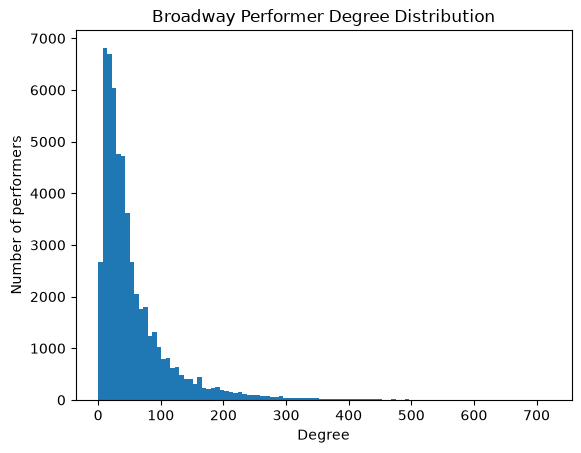

In [61]:
import matplotlib.pyplot as plt

degrees = [d for _, d in G.degree()]

plt.hist(degrees, bins=100)
plt.xlabel("Degree")
plt.ylabel("Number of performers")
plt.title("Broadway Performer Degree Distribution")
plt.show()

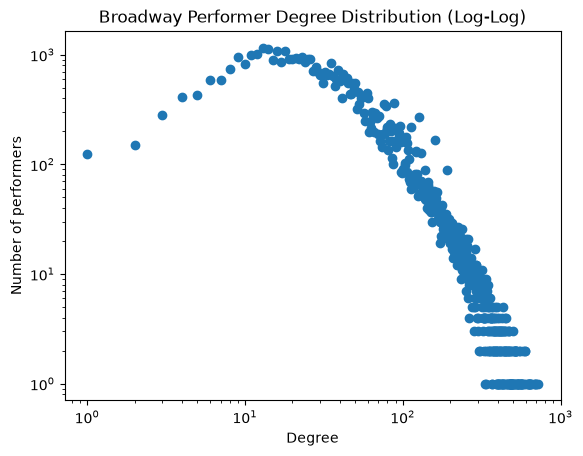

In [62]:
import numpy as np

degree_counts = pd.Series(degrees).value_counts().sort_index()

plt.loglog(
    degree_counts.index,
    degree_counts.values,
    marker="o",
    linestyle=""
)

plt.xlabel("Degree")
plt.ylabel("Number of performers")
plt.title("Broadway Performer Degree Distribution (Log-Log)")
plt.show()

In [63]:
degree_counts = (
    performer_metrics["degree"]
    .value_counts()
    .sort_index()
)

degree_counts.tail(20)

degree
576    1
578    2
584    1
593    2
595    2
602    1
619    1
625    1
632    1
633    1
634    1
640    1
642    1
649    1
652    1
675    1
692    1
698    1
700    1
720    1
Name: count, dtype: int64

In [64]:
performer_metrics["degree"].describe()

count    55261.000000
mean        56.650875
std         62.159392
min          0.000000
25%         19.000000
50%         37.000000
75%         70.000000
max        720.000000
Name: degree, dtype: float64

In [65]:
# Check isolated performers

isolated_nodes = list(nx.isolates(G))

len(isolated_nodes)

88

In [66]:
performer_metrics[
    performer_metrics["degree"] == 0
].head(10)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity,repeat_collaboration_surplus,repeat_collaboration_ratio,weighted_degree_residual,pagerank,pagerank_weighted
10593,A_35207,0,0,Maurice Chevalier,NaN,0,NaN,NaN,0.000003,0.000003
18304,A_58652,0,0,The Company of the Ballet Russe,NaN,0,NaN,NaN,0.000003,0.000003
20555,A_45753,0,0,Helen Howe,NaN,0,NaN,NaN,0.000003,0.000003
22362,A_91277,0,0,Ray Kavanaugh and His Orchestra,NaN,0,NaN,NaN,0.000003,0.000003
22507,A_36654,0,0,Dorothy Crawford,NaN,0,NaN,NaN,0.000003,0.000003
25644,A_519885,0,0,Angna Enters,NaN,0,NaN,NaN,0.000003,0.000003
29315,A_64508,0,0,Jeanne Welty,NaN,0,NaN,NaN,0.000003,0.000003
29429,A_112226,0,0,Trudi Schoop and Company,NaN,0,NaN,NaN,0.000003,0.000003
30052,A_45383,0,0,Billie Holiday,NaN,0,NaN,NaN,0.000003,0.000003
31375,A_109192,0,0,Norman Del Mar,NaN,0,NaN,NaN,0.000003,0.000003


In [71]:
# Remove isolated nodes for structural analysis

G_connected = G.subgraph(
    [
        node for node, degree in G.degree()
        if degree > 0
    ]
).copy()

print(
    "Nodes:",
    G_connected.number_of_nodes()
)

print(
    "Edges:",
    G_connected.number_of_edges()
)

Nodes: 55173
Edges: 1565292


In [72]:
G_analysis = G_connected

print("Nodes:", G_analysis.number_of_nodes())
print("Edges:", G_analysis.number_of_edges())

print(
    "Connected components:",
    nx.number_connected_components(G_analysis)
)

Nodes: 55173
Edges: 1565292
Connected components: 197


In [ ]:
largest_cc = max(
    nx.connected_components(G_analysis),
    key=len
)

G_eigen = G_analysis.subgraph(largest_cc).copy()

print(G_eigen.number_of_nodes())

52874


In [74]:
eigenvector = nx.eigenvector_centrality(
    G_eigen,
    max_iter=500
)

In [75]:
eigenvector_df = pd.DataFrame(
    eigenvector.items(),
    columns=[
        "performer_id",
        "eigenvector_centrality"
    ]
)

performer_metrics = performer_metrics.merge(
    eigenvector_df,
    on="performer_id",
    how="left"
)

In [78]:
id_columns = list(eigenvector_df.columns)

id_columns

['performer_id', 'eigenvector_centrality']

In [79]:
performer_metrics.columns.tolist()

['performer_id',
 'degree',
 'weighted_degree',
 'performer_name',
 'collaboration_intensity',
 'repeat_collaboration_surplus',
 'repeat_collaboration_ratio',
 'weighted_degree_residual',
 'pagerank',
 'pagerank_weighted',
 'eigenvector_centrality_x',
 'eigenvector_centrality_y']

In [83]:
performer_metrics = (
    performer_metrics
    .drop(columns=["eigenvector_centrality_y"])
    .rename(
        columns={
            "eigenvector_centrality_x": "eigenvector_centrality"
        }
    )
)

In [85]:
performer_metrics.sort_values(
    "eigenvector_centrality",
    ascending=False
).head(25)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity,repeat_collaboration_surplus,repeat_collaboration_ratio,weighted_degree_residual,pagerank,pagerank_weighted,eigenvector_centrality
6541,A_29775,554,607,Albert Amato,1.095668,53,0.095668,1.095668,0.000083,0.000083,0.078466
1234,A_61800,632,692,Ward Tallman,1.094937,60,0.094937,1.094937,0.000089,0.000089,0.078422
14039,A_97784,494,583,Tom Curley,1.180162,89,0.180162,1.180162,0.000073,0.000073,0.077209
3835,A_31445,593,898,Walter Beck,1.514334,305,0.514334,1.514334,0.000160,0.000160,0.076161
17277,A_42446,428,438,Herbert Goff,1.023364,10,0.023364,1.023364,0.000053,0.000053,0.076141
3562,A_68161,520,614,James MacDonald,1.180769,94,0.180769,1.180769,0.000113,0.000113,0.075849
17404,A_62258,543,626,Jerome Thor,1.152855,83,0.152855,1.152855,0.000114,0.000114,0.075656
10208,A_33750,512,597,Eileen Burns,1.166016,85,0.166016,1.166016,0.000099,0.000099,0.075263
14739,A_97806,461,471,Janice Winter,1.021692,10,0.021692,1.021692,0.000062,0.000062,0.074952
15030,A_87854,516,526,May Muth,1.019380,10,0.019380,1.019380,0.000082,0.000082,0.074778


In [86]:
performer_metrics[
    [
        "degree",
        "weighted_degree",
        "pagerank",
        "eigenvector_centrality",
        "collaboration_intensity"
    ]
].corr()

,degree,weighted_degree,pagerank,eigenvector_centrality,collaboration_intensity
degree,1.000000,0.976315,0.870435,0.379089,0.050669
weighted_degree,0.976315,1.000000,0.876880,0.367993,0.197445
pagerank,0.870435,0.876880,1.000000,0.233467,0.130233
eigenvector_centrality,0.379089,0.367993,0.233467,1.000000,0.011172
collaboration_intensity,0.050669,0.197445,0.130233,0.011172,1.000000


In [87]:
performer_metrics["eigen_minus_degree_rank"] = (
    performer_metrics["degree"].rank(ascending=False)
    -
    performer_metrics["eigenvector_centrality"].rank(ascending=False)
)

performer_metrics.sort_values(
    "eigen_minus_degree_rank",
    ascending=False
)[
    [
        "performer_name",
        "degree",
        "pagerank",
        "eigenvector_centrality"
    ]
].head(25)

,performer_name,degree,pagerank,eigenvector_centrality
24619,Shelley Hull,9,0.000005,0.001184
34534,Katherine Ross,4,0.000004,0.000728
31040,Rick Jason,7,0.000005,0.000755
29080,Jennifer Bunker,9,0.000005,0.000792
29081,A Cat,9,0.000005,0.000792
31609,James Lipton,11,0.000005,0.000862
23000,Ann Garrett,14,0.000006,0.001268
23001,Alexandra Taran,14,0.000006,0.001268
23933,Bobby Readick,16,0.000006,0.001777
18209,Noel Taylor,5,0.000004,0.000473


In [88]:
performer_metrics["degree_percentile"] = (
    performer_metrics["degree"]
    .rank(pct=True)
)

performer_metrics["eigenvector_percentile"] = (
    performer_metrics["eigenvector_centrality"]
    .rank(pct=True)
)

In [89]:
performer_metrics["eigenvector_advantage"] = (
    performer_metrics["eigenvector_percentile"]
    -
    performer_metrics["degree_percentile"]
)

performer_metrics.sort_values(
    "eigenvector_advantage",
    ascending=False
)[
    [
        "performer_name",
        "degree",
        "pagerank",
        "eigenvector_centrality",
        "eigenvector_advantage"
    ]
].head(25)

,performer_name,degree,pagerank,eigenvector_centrality,eigenvector_advantage
24619,Shelley Hull,9,0.000005,0.001184,0.814069
34534,Katherine Ross,4,0.000004,0.000728,0.793068
31040,Rick Jason,7,0.000005,0.000755,0.773087
29081,A Cat,9,0.000005,0.000792,0.752025
29080,Jennifer Bunker,9,0.000005,0.000792,0.752025
31609,James Lipton,11,0.000005,0.000862,0.738681
23933,Bobby Readick,16,0.000006,0.001777,0.733447
23001,Alexandra Taran,14,0.000006,0.001268,0.732038
23000,Ann Garrett,14,0.000006,0.001268,0.732038
18209,Noel Taylor,5,0.000004,0.000473,0.713638


In [91]:
eigen_advantage_filtered = performer_metrics[
    performer_metrics["degree"] >= 100
].copy()

eigen_advantage_filtered.sort_values(
    "eigenvector_advantage",
    ascending=False
)[
    [
        "performer_name",
        "degree",
        "pagerank",
        "eigenvector_centrality",
        "eigenvector_advantage"
    ]
].head(25)

,performer_name,degree,pagerank,eigenvector_centrality,eigenvector_advantage
21855,Bonnie Roberts,101,0.000021,0.012263,0.140640
1854,Richard Gordon,104,0.000024,0.011809,0.135355
22915,Tommy Lewis,106,0.000022,0.018814,0.131539
22920,Bob White,107,0.000023,0.019260,0.129416
6164,Ted Fetter,104,0.000019,0.005356,0.127903
24375,Sarah Floyd,100,0.000026,0.004139,0.126193
23074,Peter Cusanelli,101,0.000026,0.004023,0.123788
18546,Tanya Sanina,108,0.000018,0.006282,0.120892
13438,Fay Wray,102,0.000025,0.003678,0.119963
23480,Robert Downing,100,0.000028,0.003038,0.115564


In [92]:
largest_cc = max(
    nx.connected_components(G_analysis),
    key=len
)

G_betweenness = G_analysis.subgraph(
    largest_cc
).copy()

print(G_betweenness.number_of_nodes())

52874


In [93]:
betweenness = nx.betweenness_centrality(
    G_betweenness,
    k=500,
    seed=42
)

In [94]:
betweenness_df = pd.DataFrame(
    betweenness.items(),
    columns=[
        "performer_id",
        "betweenness"
    ]
)

performer_metrics = performer_metrics.merge(
    betweenness_df,
    on="performer_id",
    how="left"
)


In [95]:
performer_metrics[
    "betweenness"
].notna().sum()

np.int64(52874)

In [96]:
performer_metrics.sort_values(
    "betweenness",
    ascending=False
).head(30)

,performer_id,degree,weighted_degree,performer_name,collaboration_intensity,repeat_collaboration_surplus,repeat_collaboration_ratio,weighted_degree_residual,pagerank,pagerank_weighted,eigenvector_centrality,eigen_minus_degree_rank,degree_percentile,eigenvector_percentile,eigenvector_advantage,betweenness
36366,A_66920,640,928,Philip Bosco,1.450000,288,0.450000,1.450000,0.000285,0.000285,0.000992,-7233.0,0.999855,0.863052,-0.136803,0.013887
30862,A_67892,595,609,George S. Irving,1.023529,14,0.023529,1.023529,0.000179,0.000179,0.001839,-3481.5,0.999720,0.933862,-0.065858,0.009196
33873,A_57887,554,586,Chita Rivera,1.057762,32,0.057762,1.057762,0.000178,0.000178,0.000812,-9032.5,0.999466,0.828611,-0.170855,0.008850
31774,A_67151,516,528,Barbara Cook,1.023256,12,0.023256,1.023256,0.000131,0.000131,0.000952,-7488.5,0.999068,0.857397,-0.141671,0.007786
29712,A_16116,362,375,Marian Seldes,1.035912,13,0.035912,1.035912,0.000134,0.000134,0.001212,-5690.5,0.994218,0.886334,-0.107885,0.007003
36472,A_52528,396,460,John McMartin,1.161616,64,0.161616,1.161616,0.000152,0.000152,0.000477,-13616.0,0.995928,0.738227,-0.257702,0.006764
34785,A_48943,361,378,Angela Lansbury,1.047091,17,0.047091,1.047091,0.000131,0.000131,0.000333,-16723.5,0.994146,0.677592,-0.316554,0.006719
34400,A_36838,368,371,John Cullum,1.008152,3,0.008152,1.008152,0.000141,0.000141,0.000478,-13522.5,0.994580,0.738586,-0.255994,0.005864
35763,A_66722,389,408,Tom Aldredge,1.048843,19,0.048843,1.048843,0.000158,0.000158,0.000328,-16955.0,0.995621,0.674755,-0.320866,0.005623
24259,A_68950,174,179,Joyce Van Patten,1.028736,5,0.028736,1.028736,0.000071,0.000071,0.001540,-1475.0,0.948191,0.917956,-0.030235,0.005609


In [97]:
performer_metrics[
    [
        "degree",
        "weighted_degree",
        "pagerank",
        "eigenvector_centrality",
        "betweenness",
        "collaboration_intensity"
    ]
].corr()

,degree,weighted_degree,pagerank,eigenvector_centrality,betweenness,collaboration_intensity
degree,1.000000,0.976315,0.870435,0.379089,0.561716,0.050669
weighted_degree,0.976315,1.000000,0.876880,0.367993,0.553311,0.197445
pagerank,0.870435,0.876880,1.000000,0.233467,0.691177,0.130233
eigenvector_centrality,0.379089,0.367993,0.233467,1.000000,0.126374,0.011172
betweenness,0.561716,0.553311,0.691177,0.126374,1.000000,0.030799
collaboration_intensity,0.050669,0.197445,0.130233,0.011172,0.030799,1.000000


In [107]:
performer_metrics["brokerage_advantage"] = (
    performer_metrics["betweenness"].rank(pct=True)
    -
    performer_metrics["degree"].rank(pct=True)
)

In [109]:
performer_metrics["betweenness"].isna().sum()

np.int64(2387)

In [110]:
performer_metrics["betweenness"] = (
    performer_metrics["betweenness"]
    .fillna(0)
)

In [111]:
performer_metrics.sort_values(
    "brokerage_advantage",
    ascending=False
)[
    [
        "performer_name",
        "degree",
        "betweenness",
        "brokerage_advantage"
    ]
].head(20)

,performer_name,degree,betweenness,brokerage_advantage
52912,Michael Cera,9,0.000210,0.877975
54475,Nick Jonas,5,0.000076,0.870019
50951,Bill Nighy,6,0.000076,0.860845
52042,Bel Powley,13,0.001830,0.856134
52228,Gary Wilmes,7,0.000076,0.850204
47081,Catherine Byrne,12,0.000319,0.843663
37622,Josephine Baker,8,0.000076,0.838107
43612,Gilda Radner,8,0.000076,0.838107
49969,Clare Higgins,9,0.000076,0.822816
54175,Namir Smallwood,6,0.000041,0.818924


In [115]:
import numpy as np

# log-transform because degree/betweenness are heavily skewed
x = np.log1p(performer_metrics["degree"].values)
y = np.log1p(performer_metrics["betweenness"].values)

# fit y = a*x + b using numpy
slope, intercept = np.polyfit(x, y, 1)

# expected log betweenness
expected_log_betweenness = slope * x + intercept

# convert back from log scale
performer_metrics["expected_betweenness"] = (
    np.expm1(expected_log_betweenness)
)

# residual = more/less brokerage than expected
performer_metrics["brokerage_residual"] = (
    performer_metrics["betweenness"]
    -
    performer_metrics["expected_betweenness"]
)

performer_metrics.sort_values(
    "brokerage_residual",
    ascending=False
)[
    [
        "performer_name",
        "degree",
        "betweenness",
        "expected_betweenness",
        "brokerage_residual"
    ]
].head(30)

,performer_name,degree,betweenness,expected_betweenness,brokerage_residual
36366,Philip Bosco,640,0.013887,0.000286,0.013601
30862,George S. Irving,595,0.009196,0.000280,0.008917
33873,Chita Rivera,554,0.008850,0.000274,0.008577
31774,Barbara Cook,516,0.007786,0.000268,0.007518
29712,Marian Seldes,362,0.007003,0.000238,0.006765
36472,John McMartin,396,0.006764,0.000245,0.006519
34785,Angela Lansbury,361,0.006719,0.000238,0.006481
34400,John Cullum,368,0.005864,0.000239,0.005624
24259,Joyce Van Patten,174,0.005609,0.000176,0.005433
35763,Tom Aldredge,389,0.005623,0.000244,0.005379


In [116]:
performer_metrics[
    (performer_metrics["degree"] >= 50) &
    (performer_metrics["degree"] <= 200)
].sort_values(
    "brokerage_residual",
    ascending=False
)[
    [
        "performer_name",
        "degree",
        "betweenness",
        "brokerage_residual"
    ]
].head(30)

,performer_name,degree,betweenness,brokerage_residual
24259,Joyce Van Patten,174,0.005609,0.005433
16739,Robert Anderson,145,0.004020,0.003859
40726,Stockard Channing,187,0.003251,0.003068
28003,Eartha Kitt,153,0.003187,0.003022
12388,Katina Paxinou,91,0.002931,0.002810
43426,Gary Chryst,154,0.002783,0.002617
25861,Edmund Lyndeck,142,0.002633,0.002474
41816,Rudolf Nureyev,168,0.002629,0.002456
32846,Lance Avant,106,0.002468,0.002334
32606,Lois Smith,150,0.002433,0.002270


In [117]:
performer_metrics.to_csv(
    "data/processed/performer_metrics.csv",
    index=False
)

In [119]:
performer_metrics.columns

Index(['performer_id', 'degree', 'weighted_degree', 'performer_name',
       'collaboration_intensity', 'repeat_collaboration_surplus',
       'repeat_collaboration_ratio', 'weighted_degree_residual', 'pagerank',
       'pagerank_weighted', 'eigenvector_centrality',
       'eigen_minus_degree_rank', 'degree_percentile',
       'eigenvector_percentile', 'eigenvector_advantage', 'betweenness',
       'brokerage_advantage', 'expected_betweenness', 'brokerage_residual'],
      dtype='str')

In [121]:
performer_metrics["size"] = np.log1p(
    performer_metrics["degree"]
)

In [128]:
performer_metrics["show_label"] = (
    performer_metrics["degree_percentile"] >= 0.99
)

In [123]:
performer_metrics["color"] = "#4F81BD"

In [130]:
node_columns = [
    "performer_id",
    "performer_name",

    "degree",
    "weighted_degree",

    "pagerank",
    "pagerank_weighted",

    "eigenvector_centrality",
    "betweenness",

    "collaboration_intensity",
    "repeat_collaboration_ratio",

    "brokerage_advantage",

    "size",
    "color",
    "show_label"
]

performer_nodes = performer_metrics[node_columns].copy()

In [131]:
performer_nodes.head()

,performer_id,performer_name,degree,weighted_degree,pagerank,pagerank_weighted,eigenvector_centrality,betweenness,collaboration_intensity,repeat_collaboration_ratio,brokerage_advantage,size,color,show_label
0,A_473388,Dot Campbell,26,26,0.000014,0.000014,0.000010,0.00000,1.00000,0.00000,-0.051090,3.295837,#4F81BD,False
1,A_34408,Raymond Campbell,26,26,0.000014,0.000014,0.000010,0.00000,1.00000,0.00000,-0.051090,3.295837,#4F81BD,False
2,A_473389,Alice Carter,113,114,0.000028,0.000028,0.000304,0.00008,1.00885,0.00885,0.018406,4.736198,#4F81BD,False
3,A_35813,Louis Cole,26,26,0.000014,0.000014,0.000010,0.00000,1.00000,0.00000,-0.051090,3.295837,#4F81BD,False
4,A_438924,Craddock and Shadney,26,26,0.000014,0.000014,0.000010,0.00000,1.00000,0.00000,-0.051090,3.295837,#4F81BD,False


In [132]:
performer_nodes.to_csv(
    "data/processed/performer_nodes.csv",
    index=False
)

In [127]:
performer_metrics["degree_percentile"].describe()

count    55261.000000
mean         0.500009
std          0.288657
min          0.000805
25%          0.250918
50%          0.504325
75%          0.750077
max          1.000000
Name: degree_percentile, dtype: float64

In [2]:
import pandas as pd

nodes = pd.read_csv("data/processed/performer_nodes.csv")
edges = pd.read_csv("data/processed/performer_edges.csv")

print("Before:")
print(len(edges))

node_ids = set(nodes["performer_id"])

edges_clean = edges[
    edges["source"].isin(node_ids) &
    edges["target"].isin(node_ids)
]

print("After:")
print(len(edges_clean))

Before:
1566284
After:
1565292


In [3]:
edges_clean.to_csv(
    "data/processed/performer_edges_clean.csv",
    index=False
)

In [4]:
import pandas as pd

nodes = pd.read_csv("data/processed/performer_nodes.csv")
edges = pd.read_csv("data/processed/performer_edges.csv")

node_ids = set(nodes["performer_id"])

edges_clean = edges[
    edges["source"].isin(node_ids) &
    edges["target"].isin(node_ids)
]

print("Original edges:", len(edges))
print("Clean edges:", len(edges_clean))

edges_clean.to_csv(
    "data/processed/performer_edges_clean.csv",
    index=False
)

Original edges: 1566284
Clean edges: 1565292


In [5]:
bad_edges = edges_clean[
    (~edges_clean["source"].isin(node_ids)) |
    (~edges_clean["target"].isin(node_ids))
]

print(len(bad_edges))

0


In [6]:
import psutil
psutil.cpu_percent(interval=1)

28.0